# Experimental test 1 Result

* vllm기준으로 accuracy와 f1 score를 테스트
* few-shot테스트를 위해서 sc.Self_Consistency의 두번째 파라미터를 1, 2, 3, 4 로 변경하여 실험 수행
* 이외의 파라미터는 고정 
    * fewshot 테스트에 활용할 질문의 개수  : 60
    * 소스코드 포함여부  : 'Y'           
    * 반복횟수 : 5회                
    * 시스템프롬프트 'sys_prompt10'
    * self-consistency 횟수 : 5
    * temperature : 0.01
    * 엑셀버전 : 'ver7'
* 이후 결과에 대해서 스코어 비교 진행 


In [1]:
import sys, os
import re
import numpy as np
from sklearn import metrics
import pandas as pd

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
from lib.visualization.plot_generator import PlotGen
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec



In [2]:
# /mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/experiment/run_id_1/sc_vq_result_4_30_Y_30_sys_prompt10_5_0.01_ver7_0.csv
def sc_calc_acc_condition_with_temp_with_sc(run_id, llm_model, few_shot_n, test_n, q_src_yn, ver, p_ver, sc_num, temp, excel_ver):
    tmp = pd.DataFrame()
    acc_list = []
    f1_list = []
    path = f'/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/validation/{run_id}'
    file_list = os.listdir(path)
    print(f'sc_{llm_model}_result_{few_shot_n}_{test_n}_{q_src_yn}_{ver}_{p_ver}_{sc_num}_{temp}_{excel_ver}')
    opt_file = [x for x in file_list if x.startswith(f'sc_{llm_model}_result_{few_shot_n}_{test_n}_{q_src_yn}_{ver}_{p_ver}_{sc_num}_{temp}_{excel_ver}')]
    opt_file = [x for x in opt_file if x.endswith(f'.csv')]

    df = pd.DataFrame()

    
    if len(opt_file)>0 : 
        for f in opt_file:
            tmp = pd.read_csv(f'{path}/{f}', index_col =0)
            tmp = tmp.dropna()

            tmp['result'] = tmp['result_long'].apply(lambda x: int(m.group(1)) if (m := re.search(r'<Difficulty Level>\s*(\d)\s*', x)) else None)
            tmp['answer'] = tmp['answer'].apply(lambda x: int(m.group(1)) if (m := re.search(r'<Difficulty Level>\s*(\d)\s*', x)) else None)
            # tmp['answer'] = tmp['answer'].map({'Difficulty Level : Intermediate' : int(1), 'Difficulty Level : Advanced' : int(2), 'Difficulty Level : Basic' : int(0)})

            
            eval_df = tmp.groupby(['id', 'answer', 'result']).count()['question'].reset_index().rename(columns={'question' : 'count'})
            # eval_df = eval_df.sort_values(by = ['id', 'count'], ascending=[True, False]).groupby(['id', 'answer']).head(1)
            eval_df = eval_df[eval_df['count'] == sc_num]
            eval_df.loc[:, 'equal_yn'] = np.where(eval_df['answer']==eval_df['result'], 1, 0)
            acc = (eval_df['equal_yn'].sum()/eval_df.shape[0])*100  
            f1_dict = metrics.classification_report(eval_df['result'], eval_df['answer'], digits=3, output_dict=True)
            f1_list.append(f1_dict)
            acc_list.append(acc)
            df = pd.concat([df, eval_df], axis =0)
            
        df.loc[:, 'equal_yn'] = np.where(df['answer']==df['result'], 1, 0)
        y_true = df['result']
        y_pred = df['answer']
        print(f"value count for golen : {df['answer'].value_counts()}")
        print(f"value count for o_result : {df['result'].value_counts()}")
        print(metrics.classification_report(y_true, y_pred, digits=3))

        
        acc = (df['equal_yn'].sum()/df.shape[0])*100            
        print(f'{llm_model}_result_{few_shot_n}_{test_n}_{q_src_yn} : ', acc)
        return acc_list, df, f1_list





In [3]:
# sc_vq_result_4_50_Y_50_sys_prompt10_5_0.01_ver8_9.csv

internal_vali_acc_, df_, internal_vali_f1_=         sc_calc_acc_condition_with_temp_with_sc('run_id_10', 'vq', 4, 50, 'Y', 50, 'sys_prompt10', 5,  0.01, 'ver8')

sc_vq_result_4_50_Y_50_sys_prompt10_5_0.01_ver8
value count for golen : answer
1    1565
2    1088
0    1033
Name: count, dtype: int64
value count for o_result : result
1    1378
2    1250
0    1058
Name: count, dtype: int64
              precision    recall  f1-score   support

           0      0.991     0.968     0.979      1058
           1      0.847     0.962     0.900      1378
           2      0.960     0.835     0.893      1250

    accuracy                          0.921      3686
   macro avg      0.932     0.922     0.924      3686
weighted avg      0.926     0.921     0.921      3686

vq_result_4_50_Y :  92.05100379815518


In [4]:
# sc_vq_result_4_50_Y_50_sys_prompt10_5_0.01_ver8_9.csv

external_vali_acc_, df_, external_vali_f1_=         sc_calc_acc_condition_with_temp_with_sc('run_id_11', 'vq', 4, 50, 'Y', 50, 'sys_prompt10', 5,  0.01, 'ver8')

sc_vq_result_4_50_Y_50_sys_prompt10_5_0.01_ver8


/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

value count for golen : answer
1    1991
0    1137
2     327
Name: count, dtype: int64
value count for o_result : result
1    1934
0    1052
2     469
Name: count, dtype: int64
              precision    recall  f1-score   support

           0      0.798     0.862     0.829      1052
           1      0.814     0.838     0.825      1934
           2      0.743     0.518     0.611       469

    accuracy                          0.802      3455
   macro avg      0.785     0.739     0.755      3455
weighted avg      0.799     0.802     0.797      3455

vq_result_4_50_Y :  80.17366136034732


In [5]:
internal_vali_acc = [x['accuracy'] for x in internal_vali_f1_]
internal_vali_f1  = [x['weighted avg']['f1-score'] for x in internal_vali_f1_]
external_vali_acc = [x['accuracy'] for x in external_vali_f1_]
external_vali_f1  = [x['weighted avg']['f1-score'] for x in external_vali_f1_]

In [10]:
internal_vali_f1_basic  = [x['0']['f1-score'] for x in internal_vali_f1_]
internal_vali_f1_inter  = [x['1']['f1-score'] for x in internal_vali_f1_]
internal_vali_f1_advac  = [x['2']['f1-score'] for x in internal_vali_f1_]

In [27]:
np.mean(internal_vali_acc)

np.float64(0.9205569488914525)

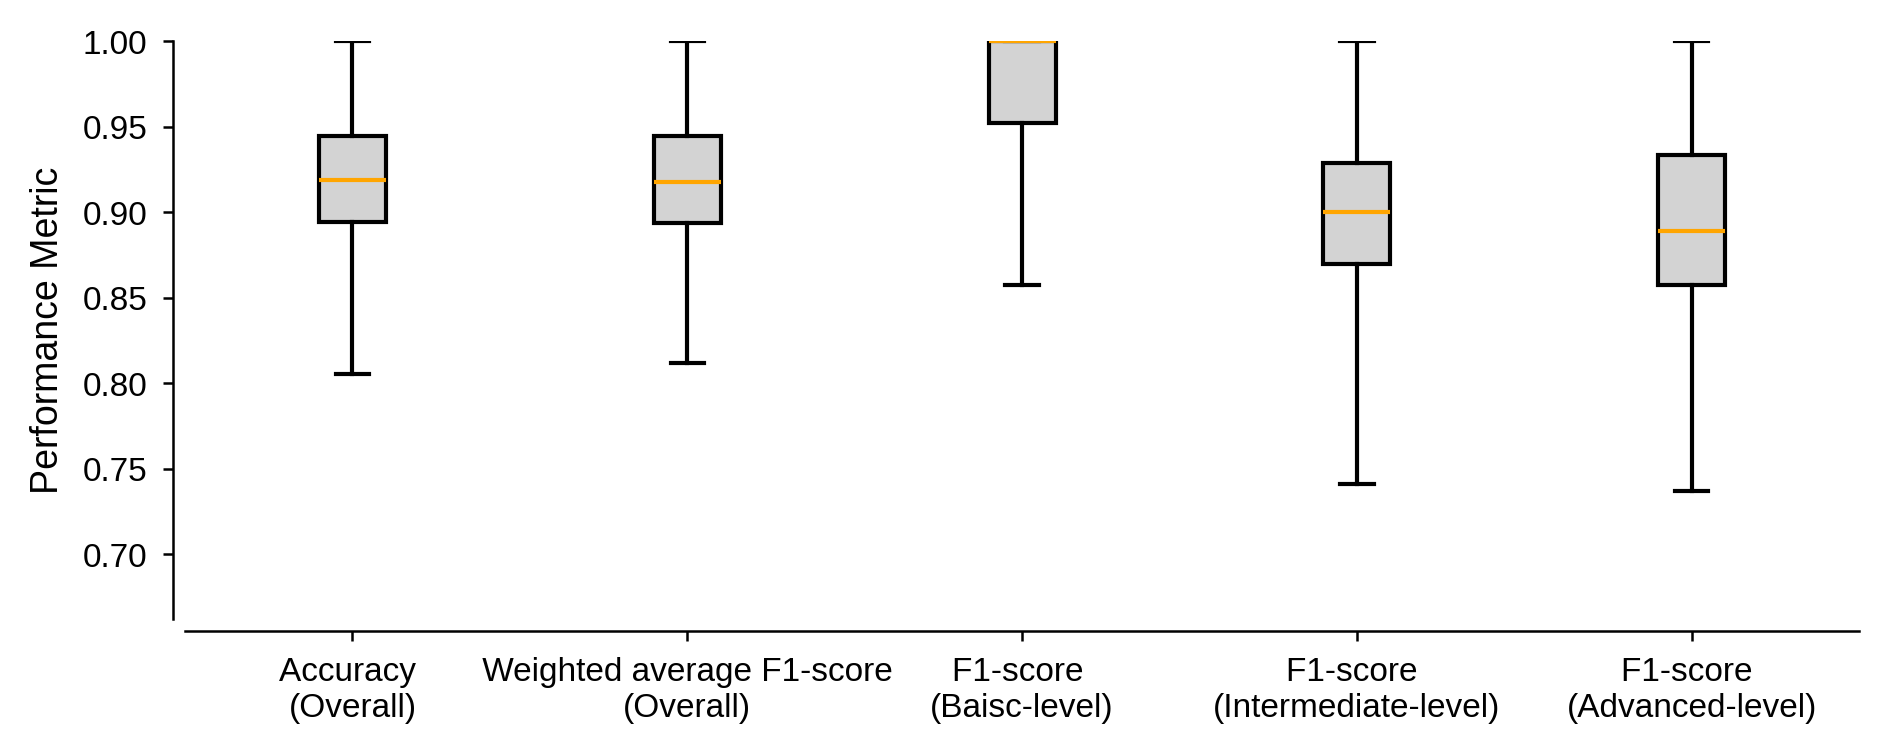

In [20]:
metrics_dict = dict()
title_list = ['Accuracy \n(Overall)', ' Weighted average F1-score \n(Overall)', 'F1-score \n(Baisc-level)', 'F1-score \n(Intermediate-level)', 'F1-score \n(Advanced-level)' ]


fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 1, figure=fig, wspace=0.2)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0])

# for i, key in enumerate(metrics_dict.keys()):
#   list_ = metrics_dict[key]
ax_a.boxplot([internal_vali_acc, internal_vali_f1, internal_vali_f1_basic, internal_vali_f1_inter, internal_vali_f1_advac],   whis = 3,
            patch_artist=True,
           boxprops=dict(linewidth=1, facecolor='lightgray'),
           medianprops=dict(color='orange', linewidth=1),
           whiskerprops=dict(linewidth=1),
           capprops=dict(linewidth=1),
           widths=0.2)


ax_a.set_xticklabels(title_list)
ax_a.set_ylabel("Performance Metric")
ax_a.set_xlabel("")  # X축 제목 제거 (깔끔하게)


ax_a.set_ylim(min(external_vali_f1), 1)
ax_a.margins(x=0.02, y=0.05)

for s in ['top', 'right']:
    ax_a.spines[s].set_visible(False)
ax_a.spines['left'].set_linewidth(0.6)
ax_a.spines['bottom'].set_linewidth(0.6)
ax_a.spines['left'].set_position(('outward', 3))
ax_a.spines['bottom'].set_position(('outward', 3))

ax_a.grid(False)

plt.savefig(f"./fig/SI_FE_2.A.5_Fig1.pdf", bbox_inches='tight', dpi=300)
# plt.show();


In [ ]:
# sc_vq_result_4_50_Y_50_sys_prompt10_5_0.01_ver8_9.csv

list_, df_ =         sc_calc_acc_condition_with_temp_with_sc('run_id_112', 'vq', 4, 30, 'Y', 30, 'sys_prompt10', 5,  0.01, 'ver7')
print(list_)

In [ ]:
golden = pd.read_csv('/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/q_output_code_y_105.csv')

In [ ]:
tmp = pd.read_csv('/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/validation/run_id_112/sc_vq_result_4_30_Y_30_sys_prompt10_5_0.01_ver7_0.csv', index_col =0)

In [ ]:
tmp.head(25)
# .apply(lambda x: int(m.group(1)) if (m := re.search(r'<Difficulty Level>\s*(\d)\s*', x)) else None)

In [ ]:
tmp['result'] = tmp['result_long'].apply(lambda x: int(m.group(1)) if (m := re.search(r'<Difficulty Level>\s*(\d)\s*', x)) else None)
tmp['answer'] = tmp['answer'].apply(lambda x: int(m.group(1)) if (m := re.search(r'<Difficulty Level>\s*(\d)\s*', x)) else None)
# tmp['answer'] = tmp['answer'].map({'Difficulty Level : Intermediate' : int(1), 'Difficulty Level : Advanced' : int(2), 'Difficulty Level : Basic' : int(0)})


In [ ]:
tmp.groupby(['id', 'answer', 'result']).count()['question'].reset_index().rename(columns={'question' : 'count'})

In [ ]:
eval_df = tmp.groupby(['id', 'answer', 'result']).count()['question'].reset_index().rename(columns={'question' : 'count'})
# eval_df = eval_df.sort_values(by = ['id', 'count'], ascending=[True, False]).groupby(['id', 'answer']).head(1)
eval_df = eval_df[eval_df['count'] == 5]

In [ ]:
eval_df.loc[:, 'equal_yn'] = np.where(eval_df['answer']==eval_df['result'], 1, 0)
acc = (eval_df['equal_yn'].sum()/eval_df.shape[0])*100  
print(acc)

In [ ]:
eval_df

In [ ]:
tmp.loc[tmp['id'] == 78046944, 'question'].values[0]

In [ ]:
tmp.groupby(['id', 'answer', 'result']).count()['question'].reset_index().rename(columns={'question' : 'count'})

In [ ]:
eval_df

In [ ]:
gold = pd.read_csv('/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/q_output_code_y_snapshot2_md.csv')

In [ ]:
vali = pd.read_csv('/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/q_output_code_y_snapshot2_validation.csv')

In [ ]:
vali[vali['id'] == 74468667]

In [ ]:
tmp[tmp['id'] == 74468667]

In [ ]:
gold = pd.read_csv('/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/q_output_code_y_snapshot2_md.csv')